In [ ]:
pip install opencv-python

The Viola-Jones algorithm, while foundational, is often implemented in OpenCV using Haar Cascade classifiers for tasks like face detection. I'll demonstrate this by loading a pre-trained face cascade and detecting faces in an image.

Please upload an image file (e.g., .jpg, .png):


Saving human.avif to human (1).avif
Uploaded file: human (1).avif


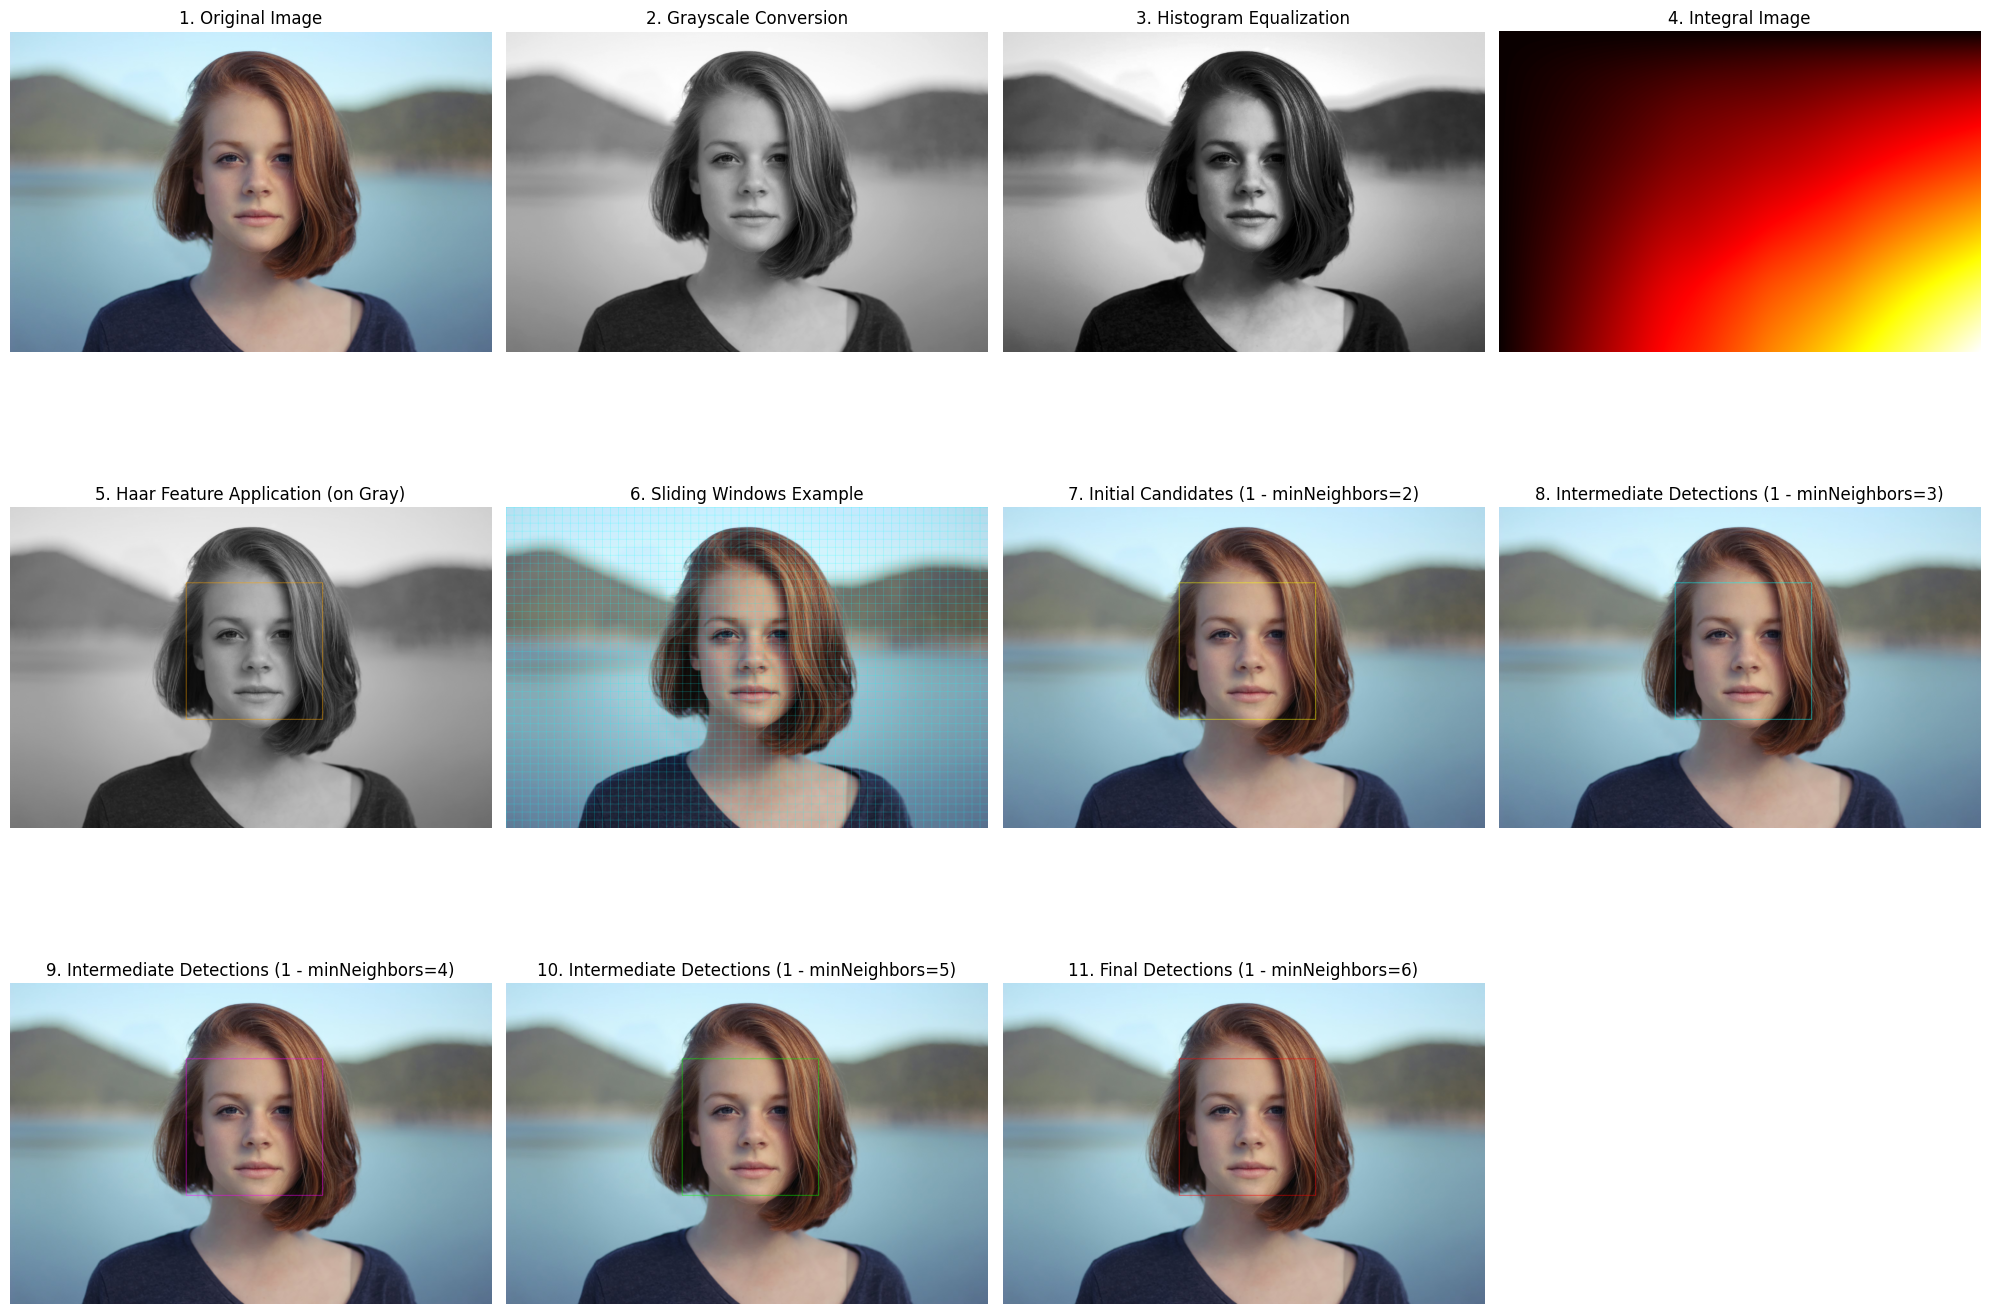

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import urllib.request
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face_cascade_path)
uploaded_file_name = None
try:
    print("Please upload an image file (e.g., .jpg, .png):")
    uploaded = files.upload()
    if uploaded:
        uploaded_file_name = list(uploaded.keys())[0]
        print(f"Uploaded file: {uploaded_file_name}")
except Exception as e:
    print(f"No file uploaded or error during upload: {e}")

img_raw = None
if uploaded_file_name:
    img_raw = cv2.imread(uploaded_file_name)
    if img_raw is None:
        print(f"Error: Could not load uploaded image '{uploaded_file_name}'.")
else:
    print("No image uploaded. Using a default image.")
    default_image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
    urllib.request.urlretrieve(default_image_url, 'default_image.jpg')
    img_raw = cv2.imread('default_image.jpg')

if img_raw is None:
    print("Fatal Error: Could not load any image (uploaded or default). Please try again.")
else:
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)
    integral_img = cv2.integral(gray)
    initial_candidates = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=2, minSize=(30, 30))
    intermediate_candidates_3 = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3, minSize=(30, 30))
    intermediate_candidates_4 = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    intermediate_candidates_5 = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    # Final, more filtered detections with higher minNeighbors
    final_faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30, 30))

    final_img = img_rgb.copy()
    for (x, y, w, h) in final_faces:
        cv2.rectangle(final_img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue for final detections

    initial_candidates_img = img_rgb.copy()
    for (x, y, w, h) in initial_candidates:
        cv2.rectangle(initial_candidates_img, (x, y), (x+w, y+h), (255, 255, 0), 2) # Yellow for initial candidates

    intermediate_candidates_img_3 = img_rgb.copy()
    for (x, y, w, h) in intermediate_candidates_3:
        cv2.rectangle(intermediate_candidates_img_3, (x, y), (x+w, y+h), (0, 255, 255), 2) # Cyan for intermediate 3

    intermediate_candidates_img_4 = img_rgb.copy()
    for (x, y, w, h) in intermediate_candidates_4:
        cv2.rectangle(intermediate_candidates_img_4, (x, y), (x+w, y+h), (255, 0, 255), 2) # Magenta for intermediate 4

    intermediate_candidates_img_5 = img_rgb.copy()
    for (x, y, w, h) in intermediate_candidates_5:
        cv2.rectangle(intermediate_candidates_img_5, (x, y), (x+w, y+h), (0, 255, 0), 2) # Green for intermediate 5

    sliding_img = img_rgb.copy()
    h_img, w_img = gray.shape
    # Example of sliding windows (simplified for visualization, not actual detection logic)
    window_size = 100
    step_size = 50 # Smaller step for better visual density and overlap
    for y in range(0, h_img - window_size + 1, step_size):
        for x in range(0, w_img - window_size + 1, step_size):
            cv2.rectangle(sliding_img, (x,y), (x+window_size,y+window_size), (0,255,255), 1) # Cyan color for visibility

    haar_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    for (x, y, w, h) in final_faces:
        cv2.rectangle(haar_vis, (x, y), (x+w, y+h), (255,165,0), 2)

    plt.figure(figsize=(20,15)) # Increased figure size for better visibility, 3 rows x 4 columns

    plt.subplot(3,4,1)
    plt.title("1. Original Image")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(3,4,2)
    plt.title("2. Grayscale Conversion")
    plt.imshow(gray, cmap='gray')
    plt.axis('off')

    plt.subplot(3,4,3)
    plt.title("3. Histogram Equalization")
    plt.imshow(hist_eq, cmap='gray')
    plt.axis('off')

    plt.subplot(3,4,4)
    plt.title("4. Integral Image")
    plt.imshow(integral_img, cmap='hot') # Using 'hot' colormap for integral image
    plt.axis('off')

    plt.subplot(3,4,5)
    plt.title("5. Haar Feature Application (on Gray)")
    plt.imshow(haar_vis)
    plt.axis('off')

    plt.subplot(3,4,6)
    plt.title("6. Sliding Windows Example")
    plt.imshow(sliding_img)
    plt.axis('off')

    plt.subplot(3,4,7)
    plt.title(f"7. Initial Candidates ({len(initial_candidates)} - minNeighbors=2)")
    plt.imshow(initial_candidates_img)
    plt.axis('off')

    plt.subplot(3,4,8)
    plt.title(f"8. Intermediate Detections ({len(intermediate_candidates_3)} - minNeighbors=3)")
    plt.imshow(intermediate_candidates_img_3)
    plt.axis('off')

    plt.subplot(3,4,9)
    plt.title(f"9. Intermediate Detections ({len(intermediate_candidates_4)} - minNeighbors=4)")
    plt.imshow(intermediate_candidates_img_4)
    plt.axis('off')

    plt.subplot(3,4,10)
    plt.title(f"10. Intermediate Detections ({len(intermediate_candidates_5)} - minNeighbors=5)")
    plt.imshow(intermediate_candidates_img_5)
    plt.axis('off')

    plt.subplot(3,4,11)
    plt.title(f"11. Final Detections ({len(final_faces)} - minNeighbors=6)")
    plt.imshow(final_img)
    plt.axis('off')

    plt.tight_layout()
    plt.show()